In [1]:
# ============================================================
# Diagnostic test for Gilman partial-wave sigma_V/m profiles
# ============================================================

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

from scipy.integrate import solve_ivp
from scipy.special import spherical_jn, spherical_yn
from scipy.special import factorial2

In [3]:
def delta_initial_small_x(ell, x_min, alpha, v_dimless):
    """
    Small-x initial phase shift estimate:
    delta_l(x_min) ≈ alpha/v * x_min^(2l+2) /
                    ((l+1) * [(2l+1)!!]^2)
    """
    denom = (ell + 1.0) * factorial2(2 * ell + 1, exact=False)**2
    return (alpha / v_dimless) * x_min**(2 * ell + 2) / denom

In [4]:
# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------

C_KM_S = 299792.458
GEV2_TO_CM2 = 0.389379e-27
GEV_TO_G = 1.78266192e-24

In [5]:
# ------------------------------------------------------------
# Variable phase equation
# ------------------------------------------------------------

def phase_rhs_diag(x, delta, ell, alpha, mchi_GeV, mphi_GeV, v_dimless):
    d = delta[0]

    jl = spherical_jn(ell, x)
    yl = spherical_yn(ell, x)

    beta = 2.0 * mphi_GeV / (mchi_GeV * v_dimless)

    bracket = np.cos(d) * jl - np.sin(d) * yl

    return [(2.0 * alpha / v_dimless) * x * np.exp(-beta * x) * bracket**2]


def compute_delta_l_diag(
    ell,
    v_km_s,
    mchi_GeV,
    mphi_MeV,
    alpha,
    x_min=1e-4,
    range_factor=120.0,
    rtol=1e-8,
    atol=1e-10,
    method="DOP853",
    max_step=np.inf,
    return_history=False,
):
    """
    Diagnostic version of phase shift calculation.
    Allows changing x_min, range_factor, method and max_step.
    """
    v_dimless = v_km_s / C_KM_S
    mphi_GeV = mphi_MeV * 1e-3

    x_max = range_factor * mchi_GeV * v_dimless / (2.0 * mphi_GeV)
    x_max = max(x_max, 50.0)

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")

        delta0 = delta_initial_small_x(
            ell=ell,
            x_min=x_min,
            alpha=alpha,
            v_dimless=v_dimless,
        )

        sol = solve_ivp(
            phase_rhs_diag,
            t_span=(x_min, x_max),
            y0=[delta0],
            args=(ell, alpha, mchi_GeV, mphi_GeV, v_dimless),
            method=method,
            rtol=rtol,
            atol=atol,
            max_step=max_step,
        )

    warning_messages = [str(w.message) for w in caught]

    if return_history:
        return sol.t, sol.y[0], sol.success, sol.message, warning_messages

    if not sol.success:
        raise RuntimeError(f"solve_ivp failed for ell={ell}, v={v_km_s}: {sol.message}")

    if len(warning_messages) > 0:
        # Not fatal, but useful for diagnostics
        pass

    return sol.y[0, -1], warning_messages


def sigma_V_over_m_diag(
    v_km_s,
    mchi_GeV,
    mphi_MeV,
    alpha,
    ell_sum_max=10,
    x_min=1e-4,
    range_factor=120.0,
    rtol=1e-8,
    atol=1e-10,
    method="DOP853",
    max_step=np.inf,
):
    """
    Diagnostic sigma_V/m.
    Returns:
        sigma_over_m_cm2_g, all_warnings
    """
    v_dimless = v_km_s / C_KM_S
    k_GeV = 0.5 * mchi_GeV * v_dimless

    deltas = []
    all_warnings = []

    for ell in range(ell_sum_max + 3):
        delta, warning_messages = compute_delta_l_diag(
            ell=ell,
            v_km_s=v_km_s,
            mchi_GeV=mchi_GeV,
            mphi_MeV=mphi_MeV,
            alpha=alpha,
            x_min=x_min,
            range_factor=range_factor,
            rtol=rtol,
            atol=atol,
            method=method,
            max_step=max_step,
            return_history=False,
        )

        deltas.append(delta)

        if len(warning_messages) > 0:
            all_warnings.extend([
                f"ell={ell}, v={v_km_s}, method={method}: {msg}"
                for msg in warning_messages
            ])

    deltas = np.asarray(deltas)

    partial_sum = 0.0

    for ell in range(ell_sum_max + 1):
        coeff = (ell + 1.0) * (ell + 2.0) / (2.0 * ell + 3.0)
        partial_sum += coeff * np.sin(deltas[ell + 2] - deltas[ell])**2

    sigma_GeV_minus2 = 4.0 * np.pi / k_GeV**2 * partial_sum

    sigma_over_m_cm2_g = (
        sigma_GeV_minus2
        * GEV2_TO_CM2
        / (mchi_GeV * GEV_TO_G)
    )

    return sigma_over_m_cm2_g, all_warnings

In [6]:
# ------------------------------------------------------------
# Choose model to diagnose
# ------------------------------------------------------------

# Multi-peak paper parameters
params = dict(
    mchi_GeV=67.7,
    mphi_MeV=1.9,
    alpha=0.00155,
)

# For single-peak, uncomment one of these:
# params = dict(mchi_GeV=31.8, mphi_MeV=5.7, alpha=0.00158)   # paper original
# params = dict(mchi_GeV=37.0, mphi_MeV=6.5, alpha=0.00158)    # email rounded
# params = dict(mchi_GeV=37.0, mphi_MeV=6.56, alpha=0.00158)   # fitted-ish


# ------------------------------------------------------------
# Diagnostic grids
# ------------------------------------------------------------

v_test = np.array([1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0, 30.0, 50.0])

configs = [
    dict(label="base DOP853",     ell_sum_max=12, x_min=1e-4, range_factor=120, rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="x_min=1e-5",      ell_sum_max=12, x_min=1e-5, range_factor=120, rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="x_min=1e-3",      ell_sum_max=12, x_min=1e-3, range_factor=120, rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="range=80",        ell_sum_max=12, x_min=1e-4, range_factor=80,  rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="range=200",       ell_sum_max=12, x_min=1e-4, range_factor=200, rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="ell=8",           ell_sum_max=8,  x_min=1e-4, range_factor=120, rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="ell=16",          ell_sum_max=16, x_min=1e-4, range_factor=120, rtol=1e-8, atol=1e-10, method="DOP853", max_step=np.inf),
    dict(label="tight tol",       ell_sum_max=12, x_min=1e-4, range_factor=120, rtol=1e-9, atol=1e-11, method="DOP853", max_step=np.inf),
    dict(label="DOP853 maxstep",  ell_sum_max=12, x_min=1e-4, range_factor=120, rtol=1e-8, atol=1e-10, method="DOP853", max_step=0.05),
    dict(label="Radau",           ell_sum_max=12, x_min=1e-4, range_factor=120, rtol=1e-8, atol=1e-10, method="Radau",  max_step=np.inf),
    dict(label="LSODA",           ell_sum_max=12, x_min=1e-4, range_factor=120, rtol=1e-8, atol=1e-10, method="LSODA",  max_step=np.inf),
]


In [7]:
# ------------------------------------------------------------
# Run sigma diagnostics
# ------------------------------------------------------------

rows = []
warnings_collected = []

for cfg in configs:
    label = cfg["label"]

    print(f"Running config: {label}")

    for v in v_test:
        try:
            sig, warns = sigma_V_over_m_diag(
                v,
                **params,
                ell_sum_max=cfg["ell_sum_max"],
                x_min=cfg["x_min"],
                range_factor=cfg["range_factor"],
                rtol=cfg["rtol"],
                atol=cfg["atol"],
                method=cfg["method"],
                max_step=cfg["max_step"],
            )

            rows.append({
                "config": label,
                "v_km_s": v,
                "sigma_cm2_g": sig,
                "n_warnings": len(warns),
            })

            warnings_collected.extend(warns)

        except Exception as e:
            rows.append({
                "config": label,
                "v_km_s": v,
                "sigma_cm2_g": np.nan,
                "n_warnings": -1,
            })
            warnings_collected.append(f"{label}, v={v}: ERROR: {e}")


df = pd.DataFrame(rows)

# Reference config
ref_label = "base DOP853"
ref = df[df["config"] == ref_label][["v_km_s", "sigma_cm2_g"]].rename(
    columns={"sigma_cm2_g": "sigma_ref"}
)

df = df.merge(ref, on="v_km_s", how="left")
df["ratio_to_base"] = df["sigma_cm2_g"] / df["sigma_ref"]
df["percent_diff"] = 100.0 * (df["ratio_to_base"] - 1.0)

print("\n=== Diagnostic table ===")
print(
    df.pivot_table(
        index="v_km_s",
        columns="config",
        values="ratio_to_base",
        aggfunc="first",
    )
)

print("\n=== Max absolute percent difference relative to base DOP853 ===")
summary = (
    df[df["config"] != ref_label]
    .groupby("config")["percent_diff"]
    .apply(lambda x: np.nanmax(np.abs(x)))
    .sort_values(ascending=False)
)
print(summary.to_frame("max_abs_percent_diff"))

print("\n=== Warning summary ===")
print(f"Total warnings/errors collected: {len(warnings_collected)}")
for msg in warnings_collected[:20]:
    print(msg)
if len(warnings_collected) > 20:
    print(f"... and {len(warnings_collected) - 20} more warnings/errors")


Running config: base DOP853
Running config: x_min=1e-5
Running config: x_min=1e-3
Running config: range=80
Running config: range=200
Running config: ell=8
Running config: ell=16
Running config: tight tol
Running config: DOP853 maxstep
Running config: Radau
Running config: LSODA

=== Diagnostic table ===
config  DOP853 maxstep     LSODA  base DOP853    ell=16     ell=8  range=200  \
v_km_s                                                                         
1.0           1.000000       NaN          1.0  1.000000  1.000000        1.0   
2.0           0.999987  1.000526          1.0  1.000000  1.000000        1.0   
5.0           0.998644  1.041692          1.0  1.000000  1.000000        1.0   
8.0           0.974178  0.688164          1.0  1.000000  1.000000        1.0   
10.0          0.999428  0.987401          1.0  1.000000  1.000000        1.0   
15.0          1.001260  1.019948          1.0  1.000000  0.999999        1.0   
20.0          1.000769  1.006079          1.0  1.000000

C:\Users\Krzysztof\AppData\Local\Temp\ipykernel_40768\1098316644.py:72: RuntimeWarning: All-NaN axis encountered
  .apply(lambda x: np.nanmax(np.abs(x)))


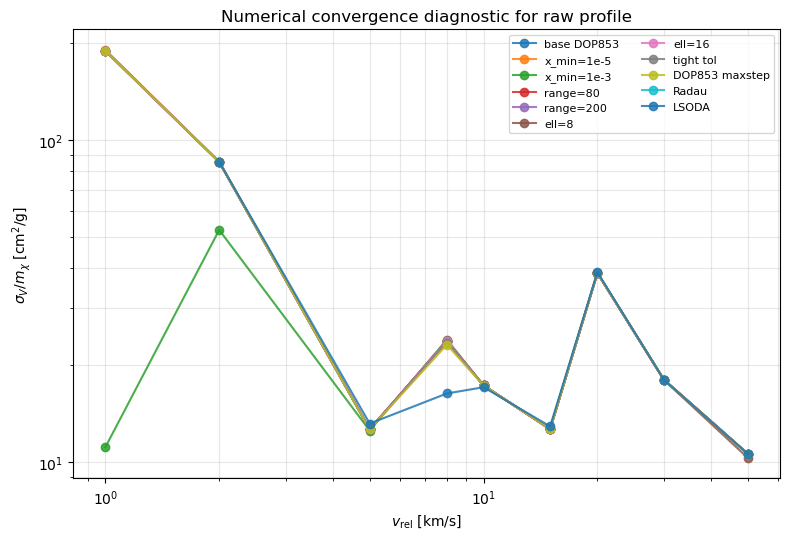

In [8]:
# ------------------------------------------------------------
# Plot sigma(v) for all configs
# ------------------------------------------------------------

plt.figure(figsize=(8.0, 5.5))

for cfg in configs:
    label = cfg["label"]
    sub = df[df["config"] == label].sort_values("v_km_s")

    plt.loglog(
        sub["v_km_s"],
        sub["sigma_cm2_g"],
        marker="o",
        lw=1.5,
        label=label,
        alpha=0.85,
    )

plt.xlabel(r"$v_{\rm rel}\ [{\rm km/s}]$")
plt.ylabel(r"$\sigma_V/m_\chi\ [{\rm cm^2/g}]$")
plt.title("Numerical convergence diagnostic for raw profile")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

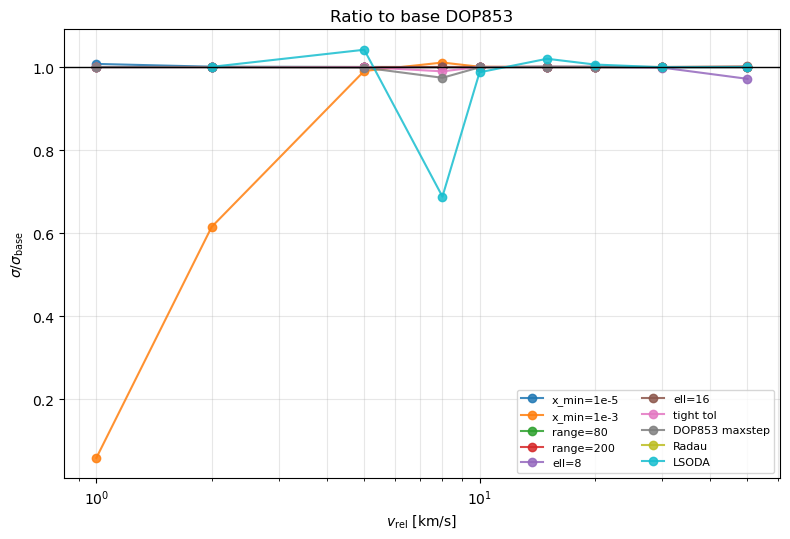

In [9]:
# ------------------------------------------------------------
# Plot ratio to base
# ------------------------------------------------------------

plt.figure(figsize=(8.0, 5.5))

for cfg in configs:
    label = cfg["label"]

    if label == ref_label:
        continue

    sub = df[df["config"] == label].sort_values("v_km_s")

    plt.semilogx(
        sub["v_km_s"],
        sub["ratio_to_base"],
        marker="o",
        lw=1.5,
        label=label,
        alpha=0.85,
    )

plt.axhline(1.0, color="black", lw=1.0)
plt.xlabel(r"$v_{\rm rel}\ [{\rm km/s}]$")
plt.ylabel(r"$\sigma / \sigma_{\rm base}$")
plt.title("Ratio to base DOP853")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


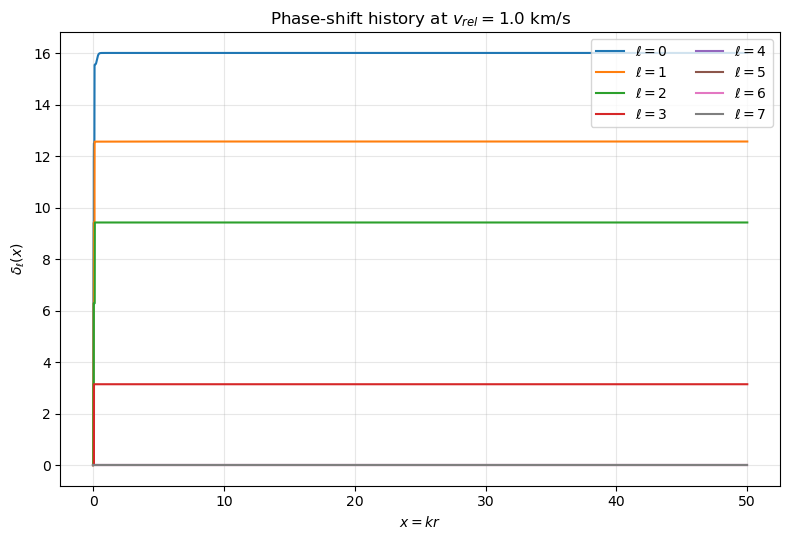

In [10]:
# ------------------------------------------------------------
# Phase history check at one problematic velocity
# ------------------------------------------------------------

v_phase = 1.0
ells_to_plot = range(0, 8)

plt.figure(figsize=(8.0, 5.5))

for ell in ells_to_plot:
    try:
        x, delta, success, message, warns = compute_delta_l_diag(
            ell=ell,
            v_km_s=v_phase,
            **params,
            x_min=1e-4,
            range_factor=120,
            rtol=1e-8,
            atol=1e-10,
            method="DOP853",
            max_step=0.05,
            return_history=True,
        )

        plt.plot(x, delta, label=fr"$\ell={ell}$")

    except Exception as e:
        print(f"Phase history failed for ell={ell}: {e}")

plt.xlabel(r"$x = k r$")
plt.ylabel(r"$\delta_\ell(x)$")
plt.title(fr"Phase-shift history at $v_{{rel}}={v_phase}$ km/s")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()